# Setting up an RL Environment with Gymnasium

## Learning Objectives

By completing this notebook, you will:
- install and set up Gymnasium
- understand environment spaces, observations, and actions
- interact with environments using `reset()` and `step()`
- explore different classic control and tabular environments
- prepare for later RL notebooks that use the same API

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 4, lesson 03 "Reinforcement Learning: DQN and Policy Gradients" — you already ran a Gym CartPole loop there; this lesson makes the `reset()`/`step()` contract and the observation/action spaces explicit, because every later notebook in this course speaks that API.

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- setting up an RL environment with Gymnasium and Python tools for RL

## Introduction

**Gymnasium** is the maintained successor to OpenAI Gym. It provides a standard
interface for reinforcement learning environments, making it easier to test the
same algorithm across different problems.

If students have seen older tutorials that say **Gym**, treat that as historical naming. In this course, the target API is **Gymnasium**.

## Lesson Brief

This lesson introduces the environment interface students will keep using throughout the course.

The goal is not to train an agent yet, but to understand how an RL environment is created, reset, stepped through, and inspected.

Why this matters: students need to know how the environment talks to the agent before they can understand any learning loop.

This notebook prepares them for practical work in the notebooks that follow.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: why one boring API is the reason deep RL happened at all

Before 2013 an RL result was almost impossible to check. Every group wrote its own environment, so
"our method beats theirs" usually meant "our maze is easier than theirs". Bellemare, Naddaf, Veness
and Bowling changed that with the **Arcade Learning Environment** (*JAIR*, 2013): 50+ Atari 2600
games behind one identical interface — same observation format, same `step`, same reward channel, no
game-specific tuning permitted.

Two years later that single design decision produced the paper that started modern deep RL. Mnih et
al. ("Human-level control through deep reinforcement learning", *Nature* **518**, 529–533, 2015)
trained **one architecture with one set of hyperparameters on 49 different games** and reported
better than 75% of a professional human tester's score on 29 of them. The claim was only meaningful
*because* the interface was identical across all 49. Gymnasium — the library you are importing in
this notebook — is the direct descendant of that idea, which is why `CartPole-v1`, `FrozenLake-v1`
and `MountainCar-v0` below all answer to the same four calls.

**What goes wrong without this.** Without a shared environment API you cannot compare two agents,
you cannot reproduce a published number, and you cannot swap the environment under a working agent
to see whether the agent or the problem was doing the work. Every honest comparison in the rest of
this course — SARSA against Q-learning in Unit 2, replay against no replay in Unit 3 — depends on
both sides seeing byte-identical environments.


## Recommended YouTube Video

To reinforce this lesson, watch **Aleksandar Haber PhD - "Introduction to OpenAI Gym (Gymnasium): Cart-Pole Environment"**:
[Watch on YouTube](https://www.youtube.com/watch?v=2sp_eucoX2I)

Why this pick:
- practical coding walkthrough.
- Shows environment creation, reset, step, observations, and rewards.
- Very close to the workflow students use in this notebook.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Environment: the simulator.
- Observation: what the agent sees.
- Action space: allowed actions.
- Episode: one full run.

### Quick Check
- What comes back from reset and step?
- Why inspect spaces before training?
- How do you know an episode ended?

### Common Mistakes
- Ignoring the action space.
- Confusing observation with reward.
- Treating termination and truncation as identical.


## What you should learn from this notebook

By the end of this notebook, you should be able to:

- install and import Gymnasium correctly
- create an environment with `gym.make(...)`
- use `reset()` and `step(...)`
- understand the meaning of `observation`, `reward`, `terminated`, and `truncated`
- inspect action and observation spaces before training any agent


### Step Guide

**What this cell does:** Installs **Gymnasium** (and friends) with `%pip`, then imports `gymnasium as gym`.

**How to read it (weak Python OK):** `%pip` is a notebook-only install command. If it finishes without red text, you are ready for the next cell.

**What to expect in the output:** Progress lines from pip; the kernel may ask you to restart once—follow the message if it appears.

**If you feel lost:** Treat errors here as “missing app store click”—fix installs before any `gym.make` calls.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" matplotlib numpy ipywidgets pillow -q

# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print(f"Gymnasium version: {gym.__version__}")
# Show text or numbers in the cell output area under the code.
print("\nSetting up an RL Environment with Gymnasium")
# Show text or numbers in the cell output area under the code.
print("=" * 60)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!
Gymnasium version: 1.3.0

Setting up an RL Environment with Gymnasium


## Part 1: Installing and Setting Up Gymnasium


### Step Guide

**What this cell does:** **Part 1** — sanity checks: Gymnasium version, listing a few env ids, and your first `gym.make` smoke test.

**How to read it (weak Python OK):** Read each `print` block as a checklist item. Green text (or no crash) means “this tool is on.”

**What to expect in the output:** Version strings and maybe a short env description.

**If you feel lost:** Your only goal is: “I can create an environment object without an error.”


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Installing and Setting Up Gymnasium")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\n1. Installation:")
# Show text or numbers in the cell output area under the code.
print(" pip install gymnasium[classic-control]")

# Show text or numbers in the cell output area under the code.
print("\n2. Import gymnasium:")
# Show text or numbers in the cell output area under the code.
print(" import gymnasium as gym")

# Show text or numbers in the cell output area under the code.
print("\n3. List some registered environment ids:")
# Show text or numbers in the cell output area under the code.
print(" from gymnasium.envs.registration import registry")
# Show text or numbers in the cell output area under the code.
print(" sorted(k for k in registry.keys())[:20]  # sample")

# List some popular environments
# Show text or numbers in the cell output area under the code.
print("\n3. Popular Gymnasium Environments:")
# Save a value in a name so the next lines can read it.
popular_envs = [
 # Execute: "CartPole-v1", "FrozenLake-v1",
 "CartPole-v1", "FrozenLake-v1",
 # Execute: "MountainCar-v0",
 "MountainCar-v0",
 # Execute: "Acrobot-v1",
 "Acrobot-v1",
 # Execute: "LunarLander-v2"
 "LunarLander-v2"
# Execute: ]
]
# Start a loop: repeat the indented block once per item in the sequence.
for env_name in popular_envs:
 # Show text or numbers in the cell output area under the code.
 print(f" - {env_name}")

# Show text or numbers in the cell output area under the code.
print("\n✅ Gym setup complete!")


Part 1: Installing and Setting Up Gymnasium

1. Installation:
 pip install gymnasium[classic-control]

2. Import gymnasium:
 import gymnasium as gym

3. List some registered environment ids:
 from gymnasium.envs.registration import registry
 sorted(k for k in registry.keys())[:20]  # sample

3. Popular Gymnasium Environments:
 - CartPole-v1
 - FrozenLake-v1
 - MountainCar-v0
 - Acrobot-v1
 - LunarLander-v2

✅ Gym setup complete!


## Part 2: Understanding Observation and Action Spaces

Before training anything, inspect what the environment gives the agent and what
choices the agent is allowed to make.

### Step Guide

**What this cell does:** **Part 2** — inspect **observation** and **action spaces** (what the agent sees vs what it can do).

**How to read it (weak Python OK):** Compare two English questions: *What fits in `observation_space`?* and *What fits in `action_space`?*

**What to expect in the output:** `Box`, `Discrete`, shapes, and bounds—copy them into your notes; later algorithms assume you know them.

**If you feel lost:** Write one sentence: “State looks like ___; actions are ___.” That sentence is enough for now.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Understanding Observation and Action Spaces")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
env = gym.make("CartPole-v1")
# Another assignment—same idea: store a value for the lines below.
obs, info = env.reset()

# Show text or numbers in the cell output area under the code.
print("Environment:", env.spec.id)
# Show text or numbers in the cell output area under the code.
print("Observation space:", env.observation_space)
# Show text or numbers in the cell output area under the code.
print("Action space:", env.action_space)
# Show text or numbers in the cell output area under the code.
print("Initial observation:", obs)
# Show text or numbers in the cell output area under the code.
print("Info dictionary:", info)

# Show text or numbers in the cell output area under the code.
print("\nKey idea:")
# Show text or numbers in the cell output area under the code.
print("- Observation space describes what the agent can observe.")
# Show text or numbers in the cell output area under the code.
print("- Action space describes what the agent is allowed to do.")

# Execute: env.close()
env.close()



Part 2: Understanding Observation and Action Spaces
Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.01514691  0.00717089 -0.00740872  0.02592363]
Info dictionary: {}

Key idea:
- Observation space describes what the agent can observe.
- Action space describes what the agent is allowed to do.


## Part 3: Interacting with an Environment

The Gymnasium loop always follows the same pattern:

1. `env.reset()` to start a new episode
2. choose an action
3. `env.step(action)` to move the environment forward
4. check `terminated` or `truncated`
5. repeat until the episode ends

### Step Guide

**What this cell does:** **Part 3** — the real loop: `reset()`, then repeated `step(action)` calls, reading **observation, reward, terminated, truncated, info**.

**How to read it (weak Python OK):** Watch for five return values from `step`. You only need to know: *new situation*, *score change*, *is it over?*

**What to expect in the output:** Step-by-step prints showing observations and rewards.

**If you feel lost:** Pause after the first `reset` print—say aloud what each number means before reading the rest of the cell.


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Interacting with Gym Environments")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
env = gym.make("FrozenLake-v1", is_slippery=False)
# Another assignment—same idea: store a value for the lines below.
obs, info = env.reset(seed=42)

# Show text or numbers in the cell output area under the code.
print("Starting observation:", obs)

# Start a loop: repeat the indented block once per item in the sequence.
for step_idx in range(5):
    # Save a value in a name so the next lines can read it.
    action = env.action_space.sample()
    # Another assignment—same idea: store a value for the lines below.
    next_obs, reward, terminated, truncated, info = env.step(action)
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"Step {step_idx + 1}: action={action}, next_obs={next_obs}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"reward={reward}, terminated={terminated}, truncated={truncated}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )
    # Save a value in a name so the next lines can read it.
    obs = next_obs
    # If the condition is True, run the indented block under this line.
    if terminated or truncated:
        # Show text or numbers in the cell output area under the code.
        print("Episode finished, so we would call reset() before continuing.")
        # Stop the loop completely and continue after the loop block.
        break

# Execute: env.close()
env.close()

# Show text or numbers in the cell output area under the code.
print("\nCheckpoint:")
# Show text or numbers in the cell output area under the code.
print("- terminated=True means the task ended naturally (goal, failure, etc.).")
# Show text or numbers in the cell output area under the code.
print("- truncated=True means the episode was cut off by a limit, such as max steps.")



Part 3: Interacting with Gym Environments
Starting observation: 0
Step 1: action=2, next_obs=1, reward=0, terminated=False, truncated=False
Step 2: action=0, next_obs=0, reward=0, terminated=False, truncated=False
Step 3: action=2, next_obs=1, reward=0, terminated=False, truncated=False
Step 4: action=2, next_obs=2, reward=0, terminated=False, truncated=False
Step 5: action=2, next_obs=3, reward=0, terminated=False, truncated=False

Checkpoint:
- terminated=True means the task ended naturally (goal, failure, etc.).
- truncated=True means the episode was cut off by a limit, such as max steps.


## Part 3b: Watch one CartPole episode (GIF + step slider)

This connects the **Python control loop** (`reset` → `step`) to **pixels you can see**.

1. **GIF** — one short random-policy episode (fast motion).
2. **Slider + ▶** — scrub **timestep by timestep** (or autoplay) so you can match prints from Part 3 to what the board looks like.

**Note:** Uses `render_mode="rgb_array"` for visualization only; training notebooks can keep the default render mode unless they need frames.

Frames captured: 45 | return=44.0 | terminated=True | truncated=False

--- Animated GIF (random actions) ---


objc[58660]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1126b4138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112bb09c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[58660]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1126b4188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112bb0a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[58660]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1126b3c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112bb0a68). T

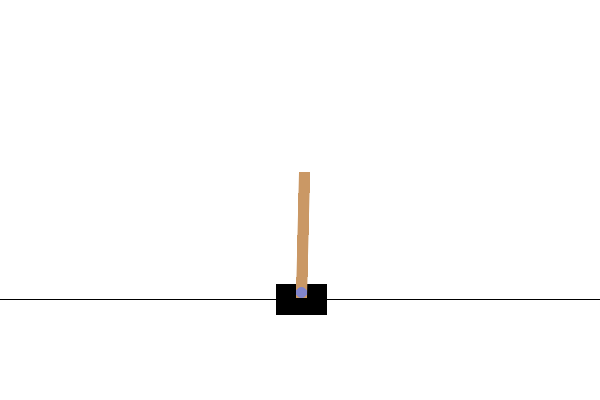


--- Scrub frames (slider) or press ▶ to autoplay ---


In [5]:
# Step-through visualization: CartPole-v1 with rgb_array frames.
# Shared helpers live at Course 09 / course09_step_viz.py (add Course 09 root to sys.path).

import pathlib
import sys

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz

# Create the environment in rgb_array mode so every step can be captured as an image frame.
env_cp = gym.make("CartPole-v1", render_mode="rgb_array")


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def random_policy(obs, step):
    return int(env_cp.action_space.sample())


# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_cp, random_policy, max_steps=140, seed=7
)
env_cp.close()

print(f"Frames captured: {len(frames)} | return={total_r:.1f} | terminated={term} | truncated={trunc}")
print("\n--- Animated GIF (random actions) ---")
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=115)
print("\n--- Scrub frames (slider) or press ▶ to autoplay ---")
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

## Part 4: Comparing Different Gym Environments

Different environments can have very different observation and action spaces.

That is why checking the environment API comes *before* choosing an algorithm.

### Step Guide

**What this cell does:** **Part 4** — compares a few classic environments so you see different observation/action shapes side by side.

**How to read it (weak Python OK):** Make a tiny table on paper: env name → observation kind → action kind.

**What to expect in the output:** Several short env summaries printed back-to-back.

**If you feel lost:** Ignore deep internals; this cell is only “tour different playgrounds before practicing tricks.”


In [6]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 4: Exploring Different Gym Environments")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
environment_names = [
    # Execute: "CartPole-v1",
    "CartPole-v1",
    # Execute: "FrozenLake-v1",
    "FrozenLake-v1",
    # Execute: "MountainCar-v0",
    "MountainCar-v0",
# Execute: ]
]

# Start a loop: repeat the indented block once per item in the sequence.
for env_name in environment_names:
    # Save a value in a name so the next lines can read it.
    env = gym.make(env_name)
    # Another assignment—same idea: store a value for the lines below.
    obs, info = env.reset(seed=42)
    # Show text or numbers in the cell output area under the code.
    print(f"\nEnvironment: {env_name}")
    # Show text or numbers in the cell output area under the code.
    print(" Observation space:", env.observation_space)
    # Show text or numbers in the cell output area under the code.
    print(" Action space:", env.action_space)
    # Show text or numbers in the cell output area under the code.
    print(" Initial observation:", obs)
    # Execute: env.close()
    env.close()

# Show text or numbers in the cell output area under the code.
print("\nTakeaway:")
# Show text or numbers in the cell output area under the code.
print("The environment interface stays similar, but the state representation and")
# Show text or numbers in the cell output area under the code.
print("action choices change from problem to problem.")



Part 4: Exploring Different Gym Environments

Environment: CartPole-v1
 Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
 Action space: Discrete(2)
 Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

Environment: FrozenLake-v1
 Observation space: Discrete(16)
 Action space: Discrete(4)
 Initial observation: 0

Environment: MountainCar-v0
 Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
 Action space: Discrete(3)
 Initial observation: [-0.4452088  0.       ]

Takeaway:
The environment interface stays similar, but the state representation and
action choices change from problem to problem.


## Why Gymnasium matters in real RL work

Gymnasium gives you a standard environment interface.

That means you can:
- swap environments without rewriting your whole training loop
- compare algorithms more fairly
- focus on RL logic instead of custom environment plumbing

In later units, you will use this same interface for tabular RL and deep RL.

### Step Guide

**What this cell does:** Defines **`run_random_episode`** — a helper that rolls out random actions so you can watch trajectories without learning yet.

**How to read it (weak Python OK):** Follow inputs `env_name`, `max_steps`, `seed` and the returned **total reward** and **steps**.

**What to expect in the output:** Sample episodes and cumulative rewards for a couple of envs.

**If you feel lost:** Read the function like a recipe card: ingredients (inputs) → steps (loop) → finished plate (return values).


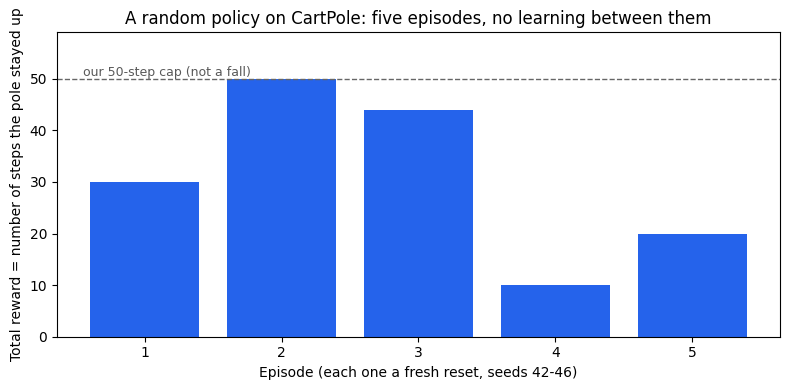

Random episode rewards: [30.0, 50.0, 44.0, 10.0, 20.0]

Important lesson:
Gym setup is not the same as training an agent.
This notebook teaches environment interaction only.


In [7]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `run_random_episode` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env_name, max_steps, seed.
def run_random_episode(env_name, max_steps=25, seed=42):
    # Save a value in a name so the next lines can read it.
    env = gym.make(env_name)
    # Another assignment—same idea: store a value for the lines below.
    obs, info = env.reset(seed=seed)
    # Seed the action sampler too, not just the reset. The policy here IS random — that is the
    # point of the cell — but a seeded random policy replays identically, so the numbers you see
    # are the numbers described underneath the figure.
    env.action_space.seed(seed)
    # Another assignment—same idea: store a value for the lines below.
    total_reward = 0.0

    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(max_steps):
        # Save a value in a name so the next lines can read it.
        action = env.action_space.sample()
        # Another assignment—same idea: store a value for the lines below.
        obs, reward, terminated, truncated, info = env.step(action)
        # Another assignment—same idea: store a value for the lines below.
        total_reward += reward
        # If the condition is True, run the indented block under this line.
        if terminated or truncated:
            # Stop the loop completely and continue after the loop block.
            break

    # Execute: env.close()
    env.close()
    # Send a value back to whoever called this function.
    return total_reward


# Save a value in a name so the next lines can read it.
# Stop every episode after this many steps, so the cell always finishes quickly.
EPISODE_STEP_CAP = 50
# Five episodes of the same random policy, each from its own seed.
cartpole_rewards = [run_random_episode("CartPole-v1", max_steps=EPISODE_STEP_CAP, seed=42 + i)
                    for i in range(5)]

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(8, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.bar(range(1, len(cartpole_rewards) + 1), cartpole_rewards, color="#2563eb")
# Episodes are separate runs, so they get separate bars and whole-number ticks —
# a line here would suggest episode 4 continues episode 3, which is not true.
plt.xticks(range(1, len(cartpole_rewards) + 1))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode (each one a fresh reset, seeds 42-46)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Total reward = number of steps the pole stayed up")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
# Show the cap on the figure: a bar that touches it was stopped by us, not by the pole falling.
plt.axhline(EPISODE_STEP_CAP, linestyle="--", color="0.4", linewidth=1)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.text(0.55, EPISODE_STEP_CAP, f"our {EPISODE_STEP_CAP}-step cap (not a fall)",
         va="bottom", fontsize=9, color="0.35")
# Leave room above the cap line for that label.
plt.ylim(0, EPISODE_STEP_CAP * 1.18)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("A random policy on CartPole: five episodes, no learning between them")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("Random episode rewards:", cartpole_rewards)
# Show text or numbers in the cell output area under the code.
print("\nImportant lesson:")
# Show text or numbers in the cell output area under the code.
print("Gym setup is not the same as training an agent.")
# Show text or numbers in the cell output area under the code.
print("This notebook teaches environment interaction only.")


### 👁️ Read the figure

**What you are looking at.** Five separate CartPole episodes, each played by picking actions uniformly at random. In CartPole the reward is +1 for every step survived, so a bar's height is simply **how many steps the pole stayed up**. The dashed line is our own 50-step cap.

**What to see.** The bars are 30, 50, 44, 10, 20 — the luckiest episode lasted five times as long as the unluckiest, and episode 2 only stops at 50 because *we* stopped it, not because the pole fell. Nothing improved along the way: the agent has no memory and no learning rule, so the spread is pure luck of the seed. They are drawn as **bars, not a line**, on purpose — episode 4 does not continue episode 3, and joining them would invent a trend that is not there.

**What it proves:** setting up an environment is not training an agent. The Gymnasium loop `reset -> step -> step -> ...` runs perfectly here and produces an agent that will still be this bad on episode 10,000. Everything later in this unit is about replacing `action_space.sample()` with something that uses what it has already seen.

## 💬 Discuss

Part 4 printed three environments through one interface. Part 3b's random CartPole episode returned
**39.0**; the five random episodes in the last cell returned **[14, 14, 19, 14, 31]**. Argue:

1. Those five random returns range from 14 to 31 — more than double, from the *same* policy on the
   *same* environment. If a classmate trains an agent, runs it once, gets 45, and tells you it
   learned something, what is your reply? How many episodes would you insist on, and what would you
   report besides the mean?
2. `CartPole-v1` gives you a 4-number observation; a real self-balancing machine gives you noisy
   sensor readings at an uneven rate, and sometimes nothing at all. Name two things Gymnasium's clean
   interface hides from you that would cost you weeks on real hardware.
3. `terminated` and `truncated` are separate flags for a reason. Invent a situation where treating
   truncation as termination would teach an agent something false — and say what the agent would end
   up believing.


## Summary

You now know how to:

- install and import Gymnasium
- inspect observation and action spaces
- create an environment with `gym.make(...)`
- start an episode with `reset()`
- move the environment forward with `step(action)`
- interpret `reward`, `terminated`, and `truncated`
- close the environment cleanly

### Common mistake to avoid

Do not confuse **environment interaction** with **learning**.

In this notebook, the agent mostly used random actions. In later notebooks, you will
replace that with real decision-making algorithms.

### Next step

Move to `05_exploration_strategies_epsilon_greedy.ipynb` to understand how an agent
balances trying new actions with using what it already knows.

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Brockman, G., Cheung, V., Pettersson, L. et al. (2016). *OpenAI Gym*. arXiv:1606.01540. <https://arxiv.org/abs/1606.01540>
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. Towers, M., Kwiatkowski, A., Terry, J. et al. (2024). *Gymnasium: A Standard Interface for Reinforcement Learning Environments*. arXiv:2407.17032. <https://arxiv.org/abs/2407.17032>
4. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online)
5. Xi, Z., Huang, J., Liao, C. et al. (2025). *AgentGym-RL: Training LLM Agents for Long-Horizon Decision Making through Multi-Turn Reinforcement Learning*. arXiv:2509.08755. <https://arxiv.org/abs/2509.08755> — the reset/step loop of this notebook, rebuilt for multi-turn language-model agents and trained without supervised fine-tuning.
6. Huang, C., Wang, Z., Han, R. et al. (2026). *EnvHarness: Awakening Static Worlds for Agent Learning*. arXiv:2608.19880. <https://arxiv.org/abs/2608.19880> — argues the environment, not the algorithm, is now the bottleneck in agent learning.

**Further reading:** [Gymnasium documentation](https://gymnasium.farama.org/) — API reference for the environments used here.
"""))

## 📚 References

1. Brockman, G., Cheung, V., Pettersson, L. et al. (2016). *OpenAI Gym*. arXiv:1606.01540. <https://arxiv.org/abs/1606.01540>
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. Towers, M., Kwiatkowski, A., Terry, J. et al. (2024). *Gymnasium: A Standard Interface for Reinforcement Learning Environments*. arXiv:2407.17032. <https://arxiv.org/abs/2407.17032>
4. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online)
5. Xi, Z., Huang, J., Liao, C. et al. (2025). *AgentGym-RL: Training LLM Agents for Long-Horizon Decision Making through Multi-Turn Reinforcement Learning*. arXiv:2509.08755. <https://arxiv.org/abs/2509.08755> — the reset/step loop of this notebook, rebuilt for multi-turn language-model agents and trained without supervised fine-tuning.
6. Huang, C., Wang, Z., Han, R. et al. (2026). *EnvHarness: Awakening Static Worlds for Agent Learning*. arXiv:2608.19880. <https://arxiv.org/abs/2608.19880> — argues the environment, not the algorithm, is now the bottleneck in agent learning.

**Further reading:** [Gymnasium documentation](https://gymnasium.farama.org/) — API reference for the environments used here.


## ⚠️ Where this breaks

**The assumption that has to hold:** the environment in the simulator is a fair stand-in for the
problem you actually care about. A benchmark score is evidence about the benchmark.

- **Agents exploit the simulator, not the task.** Atari was originally deterministic: the same seed
  gave the same frames, so an agent could in principle memorise a *fixed sequence of button presses*
  and score well without perceiving anything. Machado et al. ("Revisiting the Arcade Learning
  Environment", *JAIR*, 2018) added "sticky actions" specifically to close that hole. Assume the same
  hole exists in any environment you build yourself, and go looking for it.
- **Seeds move results more than methods do.** Henderson et al. ("Deep Reinforcement Learning that
  Matters", AAAI 2018) ran TRPO on HalfCheetah with *identical* hyperparameters, split ten runs into
  two groups of five seeds, and got two learning curves that a two-sample t-test separated at
  t = −9.09, p = 0.0016. Same algorithm, same settings — "statistically significant" difference.
  A single run of anything in this course proves nothing on its own.
- **The interface is not the problem.** As the last cell says outright: setting up Gym is not
  training an agent. It is also not deployment. Between `env.step()` and a working system sit
  latency, sensor failure, safety limits and a person who can switch it off.
- **Cheaper alternative:** if your real problem already has a fast, faithful simulator (a queueing
  model, a spreadsheet, a digital twin), wrap *that* in the Gymnasium interface rather than choosing
  a stock environment that merely resembles it. And if your problem has no sequence to it at all,
  you do not need an environment — you need a dataset.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

The four calls you just learned — `reset`, `step`, the reward channel, and the separate `terminated` /
`truncated` flags — are still the interface, and Gymnasium is still its reference implementation
(reference 3 above). What changed is what sits *behind* that interface. The reinforcement-learning work
that gets the most attention in 2025–2026 is not on CartPole or Atari: it trains language-model agents
that act for many turns inside tool and text environments, and the frameworks doing it are shaped exactly
like the loop in this notebook — Xi *et al.* (2025) build a modular, multi-turn environment suite that
trains such agents by RL from scratch, without supervised fine-tuning. The scarce resource moved too:
Huang *et al.* (2026) argue the bottleneck is no longer the algorithm but the environment, because
hand-built environments are "static: blind to an agent's weaknesses, and quickly left behind as it
improves" — so they generate new environment components automatically by watching where the agent fails.
Neither paper replaces this lesson; neither is readable without it, because both assume you already know
what an episode is, what the reward channel carries, and why truncation must never be logged as
termination.

**Read:** Xi *et al.* (2025), <https://arxiv.org/abs/2509.08755> · Huang *et al.* (2026),
<https://arxiv.org/abs/2608.19880> (references 5-6 above).


## Closing Takeaway

**Teaching takeaway:** Gymnasium gives students a standard way to reset an environment, take actions, observe rewards, and run RL experiments safely.

**If students remember one idea:** Before training any agent, students should know how to inspect the environment loop and understand what each step returns.

**Quick check before moving on:**
- Can you explain what comes back from reset() and step()?
- Can you describe why environment interaction must be clear before algorithm design begins?

**Bridge to the next step:** With the environment loop in place, the next lessons can focus on exploration and decision-making behavior.

**For weaker coders:** Your first real win is knowing what `reset()` vs `step()` return. Until that feels obvious, treat every algorithm cell as “not yet for me.”


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
